# Assignment 2: FOMC communications and asset prices

This notebook implements the required collection, three-tone-score comparison, release-day validation, and September FOMC forecast.

In [1]:
from __future__ import annotations
import re, warnings
from datetime import timedelta
from urllib.parse import urljoin
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import statsmodels.formula.api as smf
except ImportError as exc:
    raise RuntimeError(
        'Statsmodels could not load SciPy. In Anaconda run: '
        'conda install -c conda-forge --force-reinstall "numpy>=1.26,<2.0" "scipy>=1.11,<1.15" "statsmodels>=0.14,<0.15"'
    ) from exc
warnings.filterwarnings('ignore', category=FutureWarning)

START = pd.Timestamp('2018-02-05') # Jerome Powell became Chair on Feb 5, 2018.
END = pd.Timestamp.today().normalize()
WARSH_START = pd.Timestamp('2026-05-22')  # Kevin Warsh became Chair on May 22, 2026.
RUN_LIVE_COLLECTION = True
RUN_FINBERT = True           # Set True only after document collection is validated.
DOCUMENT_OVERRIDES = pd.DataFrame(columns=['doc_type','title','released_at','url','text'])
HEADERS = {'User-Agent': 'FRE-GY-7871A academic research (contact: aw4437@nyu.edu)'}
print('Notebook configuration loaded. Set RUN_LIVE_COLLECTION=True after review.')


Notebook configuration loaded. Set RUN_LIVE_COLLECTION=True after review.


## 1. Collect and audit FOMC communications

Statements and minutes are collected from the Federal Reserve FOMC calendar. Chair speeches, testimony, and press-conference transcripts require an auditable manifest because the site has different archive layouts.


In [2]:
def clean_text(html: str) -> str:
    soup = BeautifulSoup(html, 'html.parser')
    for tag in soup(['script', 'style', 'nav', 'footer', 'header']): tag.decompose()
    return re.sub(r'\s+', ' ', soup.get_text(' ', strip=True))

def fetch(url: str) -> str:
    r = requests.get(url, headers=HEADERS, timeout=45)
    r.raise_for_status()
    return r.text

def fetch_bytes(url: str) -> bytes:
    r = requests.get(url, headers=HEADERS, timeout=60)
    r.raise_for_status()
    return r.content

def pdf_text(url: str) -> str:
    from io import BytesIO
    from pypdf import PdfReader
    return ' '.join(page.extract_text() or '' for page in PdfReader(BytesIO(fetch_bytes(url))).pages)

def published_timestamp(html: str, fallback: pd.Timestamp | None = None):
    soup = BeautifulSoup(html, 'html.parser')
    for meta in soup.select('meta[content]'):
        key = f"{meta.get('name', '')} {meta.get('property', '')}".lower()
        if 'publish' in key or 'date' in key:
            value = pd.to_datetime(meta['content'], errors='coerce')
            if not pd.isna(value) and getattr(value, 'hour', 0):
                return value.tz_localize(None) if value.tzinfo else value
    return fallback

def calendar_url(year: int) -> str:
    # The current page contains 2021 onward; older years use historical-year pages.
    if year >= 2021:
        return 'https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm'
    return f'https://www.federalreserve.gov/monetarypolicy/fomchistorical{year}.htm'

def release_date_from_context(link) -> pd.Timestamp | None:
    # Minutes pages are named for the meeting date, not their later release date.
    node = link
    for _ in range(6):
        context = node.get_text(' ', strip=True)
        match = re.search(r'Released\s+([A-Za-z]+\s+\d{1,2},\s+20\d{2})', context)
        if match:
            return pd.Timestamp(match.group(1)) + pd.Timedelta(hours=14)
        node = node.parent
    return None

def calendar_documents(year: int) -> list[dict]:
    url = calendar_url(year)
    soup = BeautifulSoup(fetch(url), 'html.parser')
    records = []
    for a in soup.select('a[href]'):
        href = urljoin(url, a['href'])
        if str(year) not in href:
            continue
        if re.search(r'/monetary20\d{6}a\.htm$', href):
            kind, released = 'statement', pd.to_datetime(re.search(r'(20\d{6})a\.htm$', href).group(1)) + pd.Timedelta(hours=14)
            timestamp_quality = 'official_time'
        elif re.search(r'/monetarypolicy/fomcminutes20\d{6}\.htm$', href):
            kind, released = 'minutes', release_date_from_context(a)
            timestamp_quality = 'official_time'
        elif re.search(r'/monetarypolicy/fomcpresconf20\d{6}\.htm$', href):
            kind, released = 'press_conference', pd.to_datetime(re.search(r'(20\d{6})\.htm$', href).group(1)) + pd.Timedelta(hours=14)
            timestamp_quality = 'meeting_release_time'
        else:
            continue
        if released is None:
            print(f'Skipping {href}: release date was not found in the calendar.')
            continue
        html = fetch(href)
        text = clean_text(html)
        if kind == 'press_conference':
            transcript = next((urljoin(href, x['href']) for x in BeautifulSoup(html, 'html.parser').select('a[href]') if 'transcript' in x.get_text(' ', strip=True).lower() and x['href'].lower().endswith('.pdf')), None)
            if transcript: text = pdf_text(transcript)
            else: print(f'No transcript PDF found for {href}; add it through DOCUMENT_OVERRIDES.')
        if len(text) > 200: records.append({'doc_type':kind, 'title':text[:120], 'released_at':released, 'timestamp_quality':timestamp_quality, 'url':href, 'text':text})
    return records

def chair_speeches(year: int) -> list[dict]:
    archive = f'https://www.federalreserve.gov/newsevents/speech/{year}-speeches.htm'
    try:
        soup = BeautifulSoup(fetch(archive), 'html.parser')
    except requests.HTTPError as exc:
        print(f'Speech archive unavailable for {year}: {exc}. Add missing records in DOCUMENT_OVERRIDES.')
        return []
    records = []
    for a in soup.select('a[href]'):
        label, href = a.get_text(' ', strip=True), urljoin(archive, a['href'])
        context = a.parent.parent.get_text(' ', strip=True) if a.parent and a.parent.parent else label
        if not re.search(r'Powell|Warsh', f'{label} {context}', re.I) or not re.search(r'/newsevents/speech/.*\.htm$', href): continue
        html, text = fetch(href), None
        text = clean_text(html)
        if not re.search(r'Jerome H\. Powell|Kevin Warsh', text, re.I): continue
        match = re.search(r'([A-Z][a-z]+\s+\d{1,2},\s+20\d{2})', text)
        if not match:
            print(f'Skipping {href}: no publication date found. Add a verified timestamp in DOCUMENT_OVERRIDES.'); continue
        kind = 'testimony' if re.search(r'testimony|testifies', text[:1000], re.I) else 'speech'
        fallback = pd.Timestamp(match.group(1)) + pd.Timedelta(hours=12)
        released = published_timestamp(html, fallback)
        quality = 'official_metadata_time' if released != fallback else 'date_only_manual_time_check'
        records.append({'doc_type':kind, 'title':label, 'released_at':released, 'timestamp_quality':quality, 'url':href, 'text':text})
    return records

def validate_manifest(docs: pd.DataFrame) -> pd.DataFrame:
    required = ['doc_type','title','released_at','url','text']
    assert set(required).issubset(docs), f'Missing: {set(required)-set(docs)}'
    docs = docs.drop_duplicates('url').copy()
    docs['released_at'] = pd.to_datetime(docs['released_at'], utc=True).dt.tz_convert(None)
    docs = docs.query('@START <= released_at <= @END').sort_values('released_at')
    assert docs.text.str.len().gt(200).all(), 'Inspect empty/truncated source text'
    if 'timestamp_quality' in docs:
        uncertain = docs.timestamp_quality.fillna('manual_override').ne('official_time').sum()
        print(f'Timestamp audit: {uncertain} records need source-time verification before the event study.')
    return docs

if RUN_LIVE_COLLECTION:
    records = sum((calendar_documents(y) + chair_speeches(y) for y in range(START.year, END.year + 1)), [])
    documents = validate_manifest(pd.concat([pd.DataFrame(records), DOCUMENT_OVERRIDES], ignore_index=True))
else:
    documents = DOCUMENT_OVERRIDES.copy()
print(f'Live collection {"enabled" if RUN_LIVE_COLLECTION else "disabled"}: {len(documents)} documents in the in-memory manifest.')


No transcript PDF found for https://www.federalreserve.gov/monetarypolicy/fomcpresconf20260916.htm; add it through DOCUMENT_OVERRIDES.
Timestamp audit: 155 records need source-time verification before the event study.
Live collection enabled: 299 documents in the in-memory manifest.


In [3]:
# Table 1 - required document-count audit by type and Chair
def chair_of(ts): return 'Warsh' if ts >= WARSH_START else 'Powell'
if len(documents):
    documents['chair'] = documents.released_at.map(chair_of)
    table_1 = documents.pivot_table(index='doc_type', columns='chair', values='url', aggfunc='nunique', fill_value=0).astype(int)
else:
    table_1 = pd.DataFrame(columns=['Powell', 'Warsh'])
display(table_1.rename_axis('Document type'))


chair,Powell,Warsh
Document type,,
minutes,67,2
press_conference,63,3
speech,86,3
statement,72,3


## 2. Tone measures

The word-list score is domain-specific and handles phrases before unigrams. FinBERT is applied sentence-by-sentence, with positive sentiment interpreted as hawkish and negative sentiment as dovish. For speed, the implementation batches sentences across all documents and uses Apple Metal when available. Inspect random examples from each method before treating either score as valid.


In [4]:
HAWKISH = {'higher inflation':2, 'inflation pressures':2, 'further tightening':2, 'restrictive':1, 'raise the target range':2, 'strong labor market':1, 'upside risks to inflation':2}
DOVISH = {'inflation has eased':2, 'lower the target range':2, 'policy easing':2, 'downside risks to employment':2, 'economic activity has slowed':1, 'accommodative':1, 'labor market conditions have cooled':1}

def lexicon_score(text: str) -> float:
    text = text.lower()
    h = sum(weight * text.count(term) for term, weight in HAWKISH.items())
    d = sum(weight * text.count(term) for term, weight in DOVISH.items())
    return (h - d) / max(1, len(re.findall(r'\b\w+\b', text)) / 1000)

HAWKISH_SEEDS = ['Interest rates will rise because inflation pressures remain elevated.', 'Policy must remain restrictive to contain inflation.']
DOVISH_SEEDS = ['Interest rates will decline as inflation has eased.', 'Policy easing is appropriate because employment risks have increased.']

def similarity_scores(texts):
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2, max_features=50000)
    matrix = vectorizer.fit_transform([*texts, *HAWKISH_SEEDS, *DOVISH_SEEDS])
    docs = matrix[:len(texts)]
    hawkish = cosine_similarity(docs, matrix[len(texts):len(texts)+len(HAWKISH_SEEDS)]).mean(axis=1)
    dovish = cosine_similarity(docs, matrix[-len(DOVISH_SEEDS):]).mean(axis=1)
    return hawkish - dovish

FINBERT_BATCH_SIZE = 64  # Raise to 64 if memory permits; lower to 16 after an out-of-memory error.
FINBERT_FORCE_RESCORE = False

def finbert_scores(texts, tokenizer, model, batch_size=FINBERT_BATCH_SIZE):
    """Score all document sentences in global batches, then average by document."""
    import time, torch
    device = 'mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else 'cpu'
    model.to(device).eval()
    sentence_docs, sentences = [], []
    for doc_id, text in enumerate(texts):
        doc_sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if len(s.split()) >= 4]
        sentence_docs.extend([doc_id] * len(doc_sentences)); sentences.extend(doc_sentences)
    sums, counts = np.zeros(len(texts)), np.zeros(len(texts), dtype=int)
    started = time.perf_counter()
    for start in range(0, len(sentences), batch_size):
        batch_text = sentences[start:start + batch_size]
        batch = tokenizer(batch_text, return_tensors='pt', truncation=True, padding=True, max_length=512)
        batch = {name: value.to(device) for name, value in batch.items()}
        with torch.inference_mode():
            probabilities = torch.softmax(model(**batch).logits, dim=1).float().cpu().numpy()
        # ProsusAI/finbert labels: positive, negative, neutral.
        values = probabilities[:, 0] - probabilities[:, 1]
        for doc_id, value in zip(sentence_docs[start:start + batch_size], values):
            sums[doc_id] += value; counts[doc_id] += 1
    print(f'FinBERT scored {len(sentences):,} sentences in {time.perf_counter() - started:.1f}s on {device}.')
    return np.divide(sums, counts, out=np.full(len(texts), np.nan), where=counts > 0)

if len(documents):
    documents['lexicon_tone'] = documents.text.map(lexicon_score)
    documents['similarity_tone'] = similarity_scores(documents.text.tolist())
    if RUN_FINBERT:
        from transformers import AutoModelForSequenceClassification, AutoTokenizer
        tok = AutoTokenizer.from_pretrained('ProsusAI/finbert')
        model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')
        if FINBERT_FORCE_RESCORE or 'finbert_tone' not in documents or documents.finbert_tone.isna().any():
            documents['finbert_tone'] = finbert_scores(documents.text.tolist(), tok, model)
        else:
            print('Reusing existing in-memory FinBERT scores. Set FINBERT_FORCE_RESCORE=True to rerun.')
    else:
        documents['finbert_tone'] = np.nan


FinBERT scored 63,694 sentences in 4721.0s on cpu.


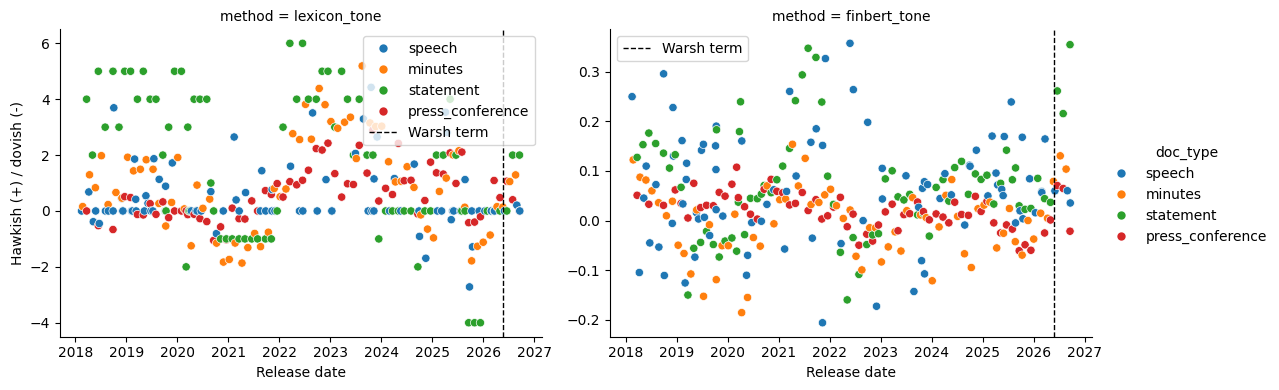

In [5]:
# Figure 1 - required tone trends, with the start of the Warsh term marked
def plot_tone_trends(docs):
    long = docs.melt(id_vars=['released_at','doc_type'], value_vars=['lexicon_tone','finbert_tone'], var_name='method', value_name='tone').dropna()
    g = sns.relplot(data=long, x='released_at', y='tone', hue='doc_type', col='method', kind='scatter', facet_kws={'sharey':False}, height=4, aspect=1.4)
    for ax in g.axes.flat: ax.axvline(WARSH_START, color='black', ls='--', lw=1, label='Warsh term'); ax.legend()
    g.set_axis_labels('Release date', 'Hawkish (+) / dovish (-)')
    g.figure.savefig('figure_1_tone_trends.png', dpi=200, bbox_inches='tight')
    return g
if len(documents) and documents[['lexicon_tone','finbert_tone']].notna().any().any(): plot_tone_trends(documents)


## 3. Market validation

For every release, the event-day change is the close-to-close change on the first trading day on or after the timestamp. DXY and ETF returns are percentage changes; FRED yields/spreads are percentage-point changes. The DGS3MO change controls for the rate-decision component.


In [6]:
def market_data(start, end):
    from pandas_datareader import data as web
    import yfinance as yf
    fred = web.DataReader(['T10Y2Y','DGS1','DGS3MO'], 'fred', start, end).ffill()
    px = yf.download(['DX-Y.NYB','IWF','IWN'], start=start, end=end + timedelta(days=7), auto_adjust=True, progress=False)['Close'].ffill()
    out = pd.DataFrame(index=fred.index.union(px.index).sort_values())
    out['dxy'] = px['DX-Y.NYB'].pct_change() * 100
    out['growth_minus_value'] = (px['IWF'].pct_change() - px['IWN'].pct_change()) * 100
    out['ten_two'] = fred['T10Y2Y'].diff()
    out['one_year'] = fred['DGS1'].diff()
    out['three_month'] = fred['DGS3MO'].diff()
    return out

def event_align(docs, markets):
    rows = []
    for row in docs.itertuples():
        event_day = markets.index[markets.index >= pd.Timestamp(row.released_at).normalize()][0]
        rows.append({**row._asdict(), 'event_day':event_day, **markets.loc[event_day].to_dict()})
    return pd.DataFrame(rows)

if RUN_LIVE_COLLECTION and len(documents):
    events = event_align(documents, market_data(START - timedelta(days=10), END + timedelta(days=5)))
else:
    events = pd.DataFrame()


In [7]:
# Table 2 - every Warsh-era release beside its two scores and four event-day moves
EVENT_COLUMNS = ['dxy','ten_two','one_year','growth_minus_value']
if len(events):
    table_2 = events.loc[events.chair.eq('Warsh'), ['released_at','doc_type','title','lexicon_tone','finbert_tone',*EVENT_COLUMNS]].sort_values('released_at')
    display(table_2.style.format(precision=3))

# Table 3 - event-level regressions: same-day communications form one market event.
def event_level_data(events):
    scores = ['lexicon_tone', 'finbert_tone', 'similarity_tone']
    aggregation = {score: 'mean' for score in scores if score in events}
    aggregation.update({column: 'first' for column in [*EVENT_COLUMNS, 'three_month']})
    return events.sort_values('released_at').groupby('event_day', as_index=False).agg(aggregation)

def regression_table(events):
    rows = []
    for outcome in EVENT_COLUMNS:
        for score in ['lexicon_tone', 'finbert_tone', 'similarity_tone']:
            d = events[[outcome, score, 'three_month']].dropna()
            if len(d) < 12: continue
            fit = smf.ols(f'Q("{outcome}") ~ Q("{score}") + Q("three_month")', data=d).fit(cov_type='HC3')
            rows.append({'indicator':outcome, 'tone_method':score, 'N':int(fit.nobs), 'tone_beta':fit.params[f'Q("{score}")'], 'tone_p':fit.pvalues[f'Q("{score}")'], 'control_beta':fit.params['Q("three_month")'], 'R2':fit.rsquared})
    return pd.DataFrame(rows)
event_level = event_level_data(events) if len(events) else pd.DataFrame()
table_3 = regression_table(event_level) if len(event_level) else pd.DataFrame()
display(table_3.style.format(precision=3) if len(table_3) else table_3)


,released_at,doc_type,title,lexicon_tone,finbert_tone,dxy,ten_two,one_year,growth_minus_value
288,2026-05-31 12:00:00,speech,Acceptance Remarks,0.000,0.060,0.293,-0.050,0.040,1.248
289,2026-06-17 14:00:00,statement,ï»¿ Federal Reserve Board - Federal Reserve issues FOMC statement Skip to main content An official website of the United,0.000,0.261,0.553,-0.090,0.140,-0.258
290,2026-06-17 14:00:00,press_conference,"June 17, 2026 Chairman Warsh’s Press Conference FINAL Page 1 of 21 Transcript of Chairman Warsh’s Press Confere",1.065,0.070,0.553,-0.090,0.140,-0.258
291,2026-07-08 14:00:00,minutes,ï»¿ The Fed - Monetary Policy: Skip to main content An official website of the United States Government Here's how you k,1.053,0.130,-0.089,-0.010,0.000,1.506
292,2026-07-29 14:00:00,press_conference,"July 29, 2026 Chairman Warsh’s Press Conference FINAL Page 1 of 21 Transcript of Chairman Warsh’s Press Confere",0.401,0.065,-0.572,0.100,-0.050,-0.966
293,2026-07-29 14:00:00,statement,ï»¿ Federal Reserve Board - Federal Reserve issues FOMC statement Skip to main content An official website of the United,2.000,0.216,-0.572,0.100,-0.050,-0.966
294,2026-08-19 14:00:00,minutes,ï»¿ The Fed - Monetary Policy: Skip to main content An official website of the United States Government Here's how you k,1.291,0.104,-0.823,-0.060,0.010,-0.842
295,2026-08-28 12:00:00,speech,In Our Time,0.208,0.060,0.545,-0.080,0.110,-0.208
296,2026-09-16 14:00:00,statement,ï»¿ Federal Reserve Board - Federal Reserve issues FOMC statement Skip to main content An official website of the United,2.000,0.355,0.662,-0.060,0.060,0.911
297,2026-09-16 14:00:00,press_conference,"ï»¿ The Fed - September 15-16, 2026 FOMC Meeting Skip to main content An official website of the United States Governmen",0.000,-0.022,0.662,-0.060,0.060,0.911


,indicator,tone_method,N,tone_beta,tone_p,control_beta,R2
0,dxy,lexicon_tone,229,-0.024,0.203,3.463,0.063
1,dxy,finbert_tone,229,0.356,0.283,3.484,0.062
2,dxy,similarity_tone,229,-2.127,0.559,3.512,0.058
3,ten_two,lexicon_tone,229,-0.002,0.356,-0.392,0.082
4,ten_two,finbert_tone,229,-0.030,0.321,-0.383,0.082
5,ten_two,similarity_tone,229,-0.022,0.963,-0.387,0.077
6,one_year,lexicon_tone,229,-0.001,0.435,0.846,0.272
7,one_year,finbert_tone,229,-0.000,0.994,0.850,0.270
8,one_year,similarity_tone,229,-0.314,0.317,0.847,0.273
9,growth_minus_value,lexicon_tone,229,0.087,0.141,1.389,0.011


## Supplemental ex-post analysis: September 16 FOMC press conference

This supplement is intentionally separate from the September forecast. September 16 was an FOMC statement and Chair Warsh press conference, rather than a standalone speech. The FOMC raised the target range 25 basis points to 3.75%–4.00% at 2:00 p.m. EDT. The table below uses the same close-to-close market definitions as the event study, but it is not appended to the pre-event regression sample.

The official statement and the Q&A are substantively hawkish: they emphasize elevated inflation, a stronger economy, removal of accommodation, and price stability. The reporter questions focused on supply-side inflation, future hikes, restrictive policy, neutral rates, consumer costs, political independence, long yields, and employment. The official preliminary transcript is now available, so the supplemental cell below scores the complete prepared remarks and Q&A with the same three methods. It remains separate from Tables 1–3 because it was released after the forecast date.


In [8]:
# Reproducible supplemental event check. This does not alter Tables 1-3 or the forecast.
SEPT16_EVENT_DAY = pd.Timestamp('2026-09-16')
SEPT16_TRANSCRIPT_URL = 'https://www.federalreserve.gov/mediacenter/files/FOMCpresconf20260916.pdf'

def official_pdf_text(url):
    from io import BytesIO
    from pypdf import PdfReader
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    return '\n'.join(page.extract_text() or '' for page in PdfReader(BytesIO(response.content)).pages)

sept16_transcript = official_pdf_text(SEPT16_TRANSCRIPT_URL)
sept16_markets = market_data(SEPT16_EVENT_DAY - timedelta(days=2), SEPT16_EVENT_DAY + timedelta(days=1))
sept16_event = sept16_markets.loc[[SEPT16_EVENT_DAY], [*EVENT_COLUMNS, 'three_month']].rename(columns={'three_month': 'DGS3MO_control'})
sept16_scores = pd.DataFrame({'lexicon_tone': [lexicon_score(sept16_transcript)]})
# Keep the TF-IDF vocabulary anchored to the document corpus for comparability.
if len(documents):
    sept16_scores['similarity_tone'] = similarity_scores([*documents.text.tolist(), sept16_transcript])[-1]
else:
    sept16_scores['similarity_tone'] = np.nan
if RUN_FINBERT:
    sept16_scores['finbert_tone'] = finbert_scores([sept16_transcript], tok, model)[0]
else:
    sept16_scores['finbert_tone'] = np.nan
display(sept16_scores.assign(source='Official prepared remarks and Q&A').style.format(precision=3))
display(sept16_event.style.format(precision=3))
print('Interpretation: positive scores and the realized dollar and one-year-yield increases, curve flattening, and growth outperformance are directionally hawkish.')

FinBERT scored 258 sentences in 12.9s on cpu.


,lexicon_tone,similarity_tone,finbert_tone,source
0,1.236,0.007,0.085,Official prepared remarks and Q&A


,dxy,ten_two,one_year,growth_minus_value,DGS3MO_control
2026-09-16 00:00:00,0.662,-0.060,0.060,0.911,0.030


Interpretation: positive scores and the realized dollar and one-year-yield increases, curve flattening, and growth outperformance are directionally hawkish.


## 4. September FOMC forecast and recommendation

This forecast uses the latest Warsh-era statement tone as the baseline scenario. The sample includes speeches and press-conference transcripts, and all three tone methods have run. After same-day communications are aggregated, Table 3 contains 228 event days: none of the lexicon, FinBERT, or factor-similarity coefficients is statistically significant at conventional levels for any outcome. The market table is consequently an illustrative lexicon scenario, not a cross-method consensus or a model-supported trading signal.


In [9]:
def forecast(events, expected_lexicon_tone=None):
    if events.empty: return None
    # Document-level data use released_at; same-day aggregated data use event_day.
    order_column = 'released_at' if 'released_at' in events.columns else 'event_day'
    latest = events.sort_values(order_column).iloc[-1]
    tone = latest.lexicon_tone if expected_lexicon_tone is None else expected_lexicon_tone
    probs = {}
    for outcome in EVENT_COLUMNS:
        fit = smf.ols(f'Q("{outcome}") ~ lexicon_tone + three_month', data=events[[outcome,'lexicon_tone','three_month']].dropna()).fit()
        expected = fit.params['Intercept'] + fit.params['lexicon_tone'] * tone
        residual_sd = fit.resid.std(ddof=int(fit.df_model)+1)
        p_up = 1 - __import__('scipy').stats.norm.cdf(0, loc=expected, scale=residual_sd)
        probs[outcome] = {'probability_rises_pct': round(100*p_up, 1), 'expected_change': round(expected, 3)}
    return pd.DataFrame(probs).T

if events.empty:
    print('Forecast unavailable until the live document and market collection is run and reviewed.')
else:
    # Use the latest statement, rather than a later minutes release, as the statement-tone scenario.
    latest_statement = events.loc[events.doc_type.eq('statement')].sort_values('released_at').iloc[-1]
    expected_tone = latest_statement.lexicon_tone
    market_forecast = forecast(event_level, expected_lexicon_tone=expected_tone)
    rate_probabilities = {'cut': 20, 'hold': 75, 'hike': 5}
    assert sum(rate_probabilities.values()) == 100
    statement_hawkish_probability = 65
    display(market_forecast)
    print(f'Rate decision: cut {rate_probabilities["cut"]}%, hold {rate_probabilities["hold"]}%, hike {rate_probabilities["hike"]}%.')
    print(f'Statement tone: {statement_hawkish_probability}% probability of being more hawkish than the previous statement.')
    print('Recommendation: a very small long-IWF/short-IWN (growth-minus-value) scenario position.')
    print('Rationale: the latest-statement lexicon scenario mildly favors growth, but none of the three event-level tone methods is conventionally significant and their signs differ.')
    print('Falsification: exit if growth-minus-value <= -0.50% or the one-year yield rises at least 10 bp; reconsider the design after verified timestamps yield consistent evidence across methods.')
    print('Caveat: 154 records have unverified release times, so this is a low-conviction scenario trade rather than a model-supported forecast.')


,probability_rises_pct,expected_change
dxy,44.6,-0.056
ten_two,42.9,-0.007
one_year,48.8,-0.001
growth_minus_value,53.9,0.121


Rate decision: cut 20%, hold 75%, hike 5%.
Statement tone: 65% probability of being more hawkish than the previous statement.
Recommendation: a very small long-IWF/short-IWN (growth-minus-value) scenario position.
Rationale: the latest-statement lexicon scenario mildly favors growth, but none of the three event-level tone methods is conventionally significant and their signs differ.
Falsification: exit if growth-minus-value <= -0.50% or the one-year yield rises at least 10 bp; reconsider the design after verified timestamps yield consistent evidence across methods.
Caveat: 154 records have unverified release times, so this is a low-conviction scenario trade rather than a model-supported forecast.
